In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [5]:
# Data Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

training_set = train_datagen.flow_from_directory(
    'training_set',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    'test_set',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [16]:
# Build CNN Model
model = models.Sequential()

# Input Layer
model.add(tf.keras.Input(shape=(64,64,3)))

# Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [12]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    training_set,
    epochs=10,
    validation_data=test_set
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 95s 342ms/step - accuracy: 0.5743 - loss: 0.6830 - val_accuracy: 0.6693 - val_loss: 0.6334
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 119s 474ms/step - accuracy: 0.6751 - loss: 0.6017 - val_accuracy: 0.6372 - val_loss: 0.6751
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 168s 667ms/step - accuracy: 0.7099 - loss: 0.5611 - val_accuracy: 0.7385 - val_loss: 0.5300
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 88s 349ms/step - accuracy: 0.7320 - loss: 0.5300 - val_accuracy: 0.7538 - val_loss: 0.5210
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 126s 504ms/step - accuracy: 0.7564 - loss: 0.5006 - val_accuracy: 0.7706 - val_loss: 0.4974
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 521ms/step - accuracy: 0.7675 - loss: 0.4800 - val_accuracy: 0.7622 - val_loss: 0.5051
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 598ms/step - accuracy: 0.7776 - loss: 0.4657 - val_accuracy: 0.7776 - val_loss: 0.4766
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 583ms/step - accuracy: 0.7876 - l

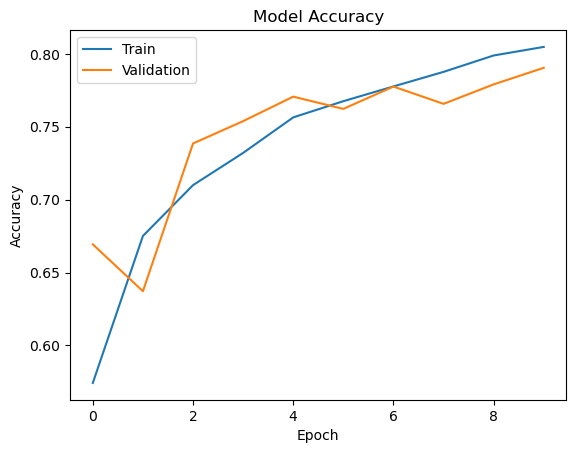

In [13]:
# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

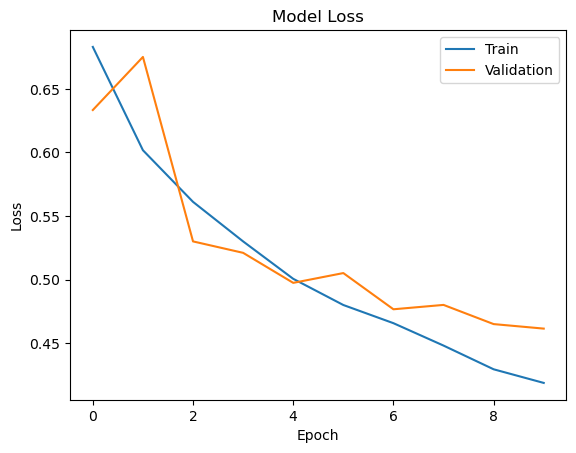

In [14]:
# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [18]:
# Save Model
model.save("cat_dog_classifier.keras")
print("Model Trained Successfully!")

Model Trained Successfully!
